## Proyecto de Redes Neuronales Recurrentes
###Long Short-Term Memory
Lizeth J. Orozco García

En este proyecto se crear un modelo usando LSTM para el análisis de datos sísmicos en México, los cuales son un ejemplo de datos sequenciales y temporales (Kushal et al., 2025).

### Librerias

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.impute import SimpleImputer

import plotly.graph_objects as go
from sklearn.metrics import r2_score

### Base de Datos
Se utilizó la base de datos recuperada en la página http://www.ssn.unam.mx/sismicidad/ultimos/. Específicamente se eligió que los sismos fueran de magnitudes de 5.5 ó mayores, ya que éstos presentan la energía sísmica necesaria para poder ser detectados (Kushal et al., 2025).
La base de datos:
**Sismicidad del 1965-09-01 al 2023-12-31, mag. 5.5 a 9.9, todas las profundidades, lat. 15.13 a 32.26, long. -118.0 a -85.0.**

In [18]:
data = pd.read_csv('/content/drive/MyDrive/Ciencia de Datos/Proyectos/Proyectos MV/SSNMX_catalogo_19650901_20231231_m55_99_lat15d13_32d26_lon-118d0_-85d0.csv',skiprows=4,skipfooter=7,engine="python",encoding="latin1")
data = pd.DataFrame(data)
data.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,1965-12-09,00:07:51,6.5,17.249,-100.070,65.0,"27 km al NORTE de COYUCA DE BENITEZ, GRO",1965-12-09,06:07:51,revisado
1,1968-07-01,21:44:52,6.7,17.508,-100.256,62.0,"38 km al NORESTE de ATOYAC DE ALVAREZ, GRO",1968-07-02,03:44:52,revisado
2,1968-08-02,08:06:37,7.3,16.600,-97.800,16.0,"39 km al NORESTE de PINOTEPA NACIONAL, OAX",1968-08-02,14:06:37,revisado
3,1968-11-28,04:36:08,6.6,15.231,-94.775,23.0,"114 km al SURESTE de SALINA CRUZ, OAX",1968-11-28,10:36:08,revisado
4,1969-08-17,14:13:09,6.5,25.250,-109.240,15.0,"65 km al SUROESTE de LOS MOCHIS, SIN",1969-08-17,20:13:09,revisado


In [19]:
data = data[['Fecha','Hora','Magnitud','Latitud','Longitud','Profundidad']]
data.head(2)

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad
0,1965-12-09,00:07:51,6.5,17.249,-100.070,65.0
1,1968-07-01,21:44:52,6.7,17.508,-100.256,62.0


In [20]:
data['Datetime'] = pd.to_datetime(data['Fecha'] + ' ' + data['Hora'])
data.head(2)

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Datetime
0,1965-12-09,00:07:51,6.5,17.249,-100.070,65.0,1965-12-09 00:07:51
1,1968-07-01,21:44:52,6.7,17.508,-100.256,62.0,1968-07-01 21:44:52


In [21]:
data.drop(['Fecha','Hora'],axis=1,inplace=True)
data.head(2)

,Magnitud,Latitud,Longitud,Profundidad,Datetime
0,6.5,17.249,-100.070,65.0,1965-12-09 00:07:51
1,6.7,17.508,-100.256,62.0,1968-07-01 21:44:52


In [22]:
data.set_index('Datetime', inplace=True)
data.head(2)

,Magnitud,Latitud,Longitud,Profundidad
Datetime,,,,
1965-12-09 00:07:51,6.5,17.249,-100.070,65.0
1968-07-01 21:44:52,6.7,17.508,-100.256,62.0


In [23]:
data.isna().sum()

,0
Magnitud,0
Latitud,0
Longitud,0
Profundidad,0


### Data Normalization

In [24]:
scaler = MinMaxScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
data_scaled.head()

,Magnitud,Latitud,Longitud,Profundidad
0,0.384615,0.123991,0.548064,0.294393
1,0.461538,0.139146,0.541819,0.280374
2,0.692308,0.086015,0.624282,0.065421
3,0.423077,0.005910,0.725850,0.098131
4,0.384615,0.592159,0.240171,0.060748


### Análisis Exploratorio Descriptivo

In [27]:
data.describe()

,Magnitud,Latitud,Longitud,Profundidad
count,375.000000,375.000000,375.000000,375.000000
mean,5.981067,18.998149,-102.038737,31.310133
std,0.534519,4.010688,6.330223,34.091080
min,5.500000,15.130000,-116.393000,2.000000
25%,5.600000,16.214000,-107.045000,10.000000
50%,5.800000,17.750000,-101.230000,16.900000
75%,6.200000,19.125400,-97.409500,34.000000
max,8.100000,32.220000,-86.610000,216.000000


In [28]:
data.corr()

,Magnitud,Latitud,Longitud,Profundidad
Magnitud,1.000000,-0.031520,0.043100,0.014725
Latitud,-0.031520,1.000000,-0.814409,-0.288773
Longitud,0.043100,-0.814409,1.000000,0.490599
Profundidad,0.014725,-0.288773,0.490599,1.000000


<Axes: >

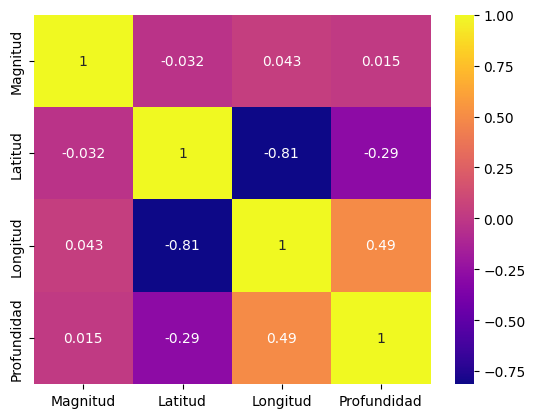

In [29]:
sns.heatmap(data.corr(), annot=True, cmap="plasma")

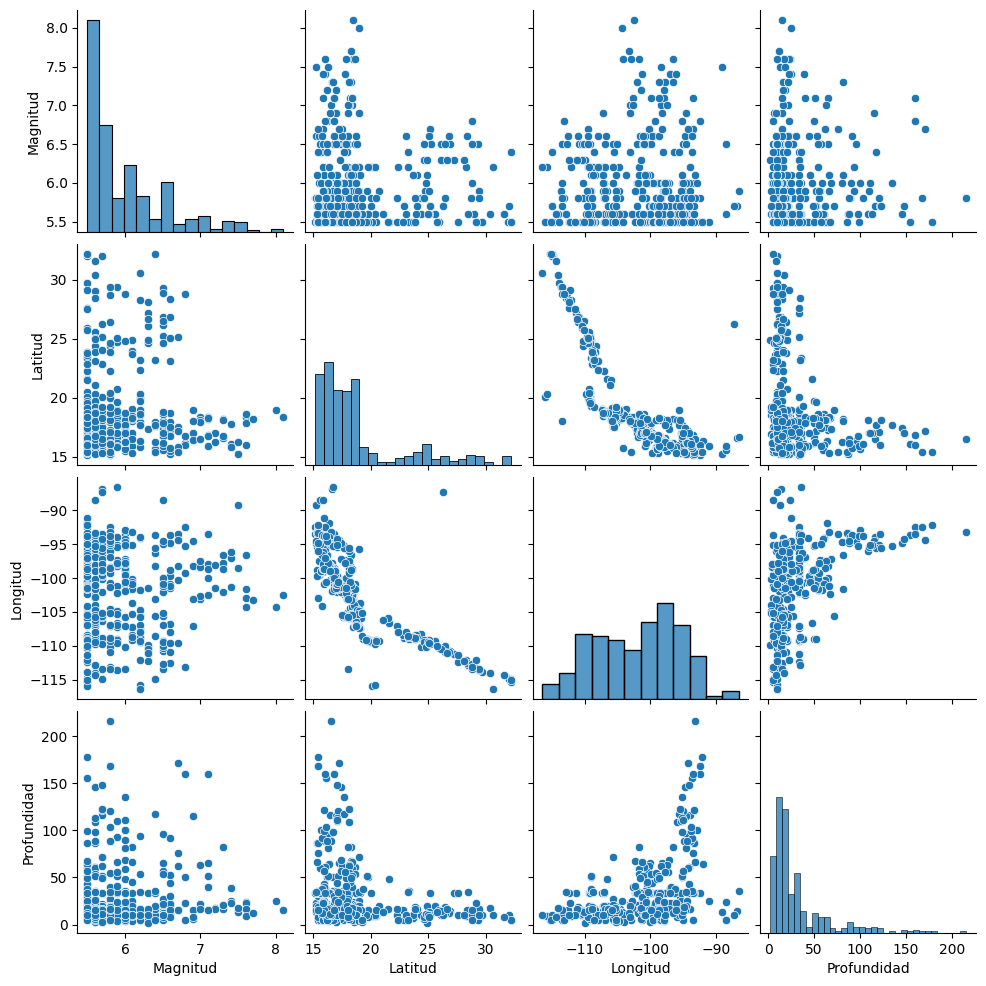

In [30]:
sns.pairplot(data)

### Creación del modelo

In [25]:
#X = data_scaled[['Latitud','Longitud','Profundidad']]
#y = data_scaled['Magnitud']



In [36]:
data_train, data_test = train_test_split(data, test_size=0.2, random_state=123, shuffle=False)


In [37]:
imputer = SimpleImputer(strategy='mean')
data_train = pd.DataFrame(imputer.fit_transform(data_train), columns=data_train.columns, index=data_train.index)
data_train

,Magnitud,Latitud,Longitud,Profundidad
Datetime,,,,
1965-12-09 00:07:51,6.5,17.2490,-100.0700,65.0
1968-07-01 21:44:52,6.7,17.5080,-100.2560,62.0
1968-08-02 08:06:37,7.3,16.6000,-97.8000,16.0
1968-11-28 04:36:08,6.6,15.2310,-94.7750,23.0
1969-08-17 14:13:09,6.5,25.2500,-109.2400,15.0
...,...,...,...,...
2014-09-06 14:22:58,5.9,18.6870,-106.9520,10.0
2014-09-08 15:30:38,5.5,16.1178,-98.3397,8.0
2014-10-04 14:16:36,5.6,17.4185,-94.8220,145.8


In [39]:
# Escalado de datos
scaler = MinMaxScaler(feature_range=(0, 1))    ###transforma los datos en ceros y uno
train_scaled = scaler.fit_transform(data_train)
print(train_scaled)

# Crear secuencias de temporales, datos para el entrenamiento
def create_dataset(dataset, look_back=60):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

X_train, y_train = create_dataset(train_scaled, 60)

[[0.38461538 0.12399064 0.54217687 0.29439252]
 [0.46153846 0.1391457  0.53585034 0.28037383]
 [0.69230769 0.08601521 0.61938776 0.06542056]
 ...
 [0.03846154 0.13390872 0.72068027 0.67196262]
 [0.23076923 0.50124634 0.24676871 0.03738318]
 [0.03846154 0.05248683 0.69245918 0.03738318]]


In [40]:
X_train.shape

(240, 60, 4)

In [41]:
# Modelo LSTM
model = Sequential([
    LSTM(100, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),  #return_sequences=True Devuelve salidas para cada paso (necesario para apilar LSTM)
    Dropout(0.2), #evita el sobreajuste , apaga aleatoriamete el 20% de las neuronas durante el entrenamiento#
    LSTM(100, return_sequences=False), #return sequences = False nos da la salid final y no toda la secuencia
    Dense(1) #capa final densa
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,501 (478.52 KB)

 Trainable params: 122,501 (478.52 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Entrenar el modelo
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.3502
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0453
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0422
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0394
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0429
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0374
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0409
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0372
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0373
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0409
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - loss: 0.0331
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0411
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0389
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0350
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0358
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━

In [51]:
# Preparar los datos reales de 2024 para comparación
imputer = SimpleImputer(strategy='mean')
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns, index=data.index)
data_scaled = scaler.fit_transform(data)

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 375 entries, 1965-12-09 00:07:51 to 2023-12-07 14:03:40
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Magnitud     375 non-null    float64
 1   Latitud      375 non-null    float64
 2   Longitud     375 non-null    float64
 3   Profundidad  375 non-null    float64
dtypes: float64(4)
memory usage: 14.6 KB


In [53]:
# Crear datos de entrada para predicción
X_real, _ = create_dataset(np.vstack([train_scaled[-60:], data_scaled]), 60)

# Predicciones
predictions_scaled = model.predict(X_real)
predictions = scaler.inverse_transform(np.concatenate([predictions_scaled, np.zeros((len(predictions_scaled),3 ))], axis=1))[:, 0]

# Datos reales para comparar
real_demand = scaler.inverse_transform(data_scaled)[:, 0]


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step


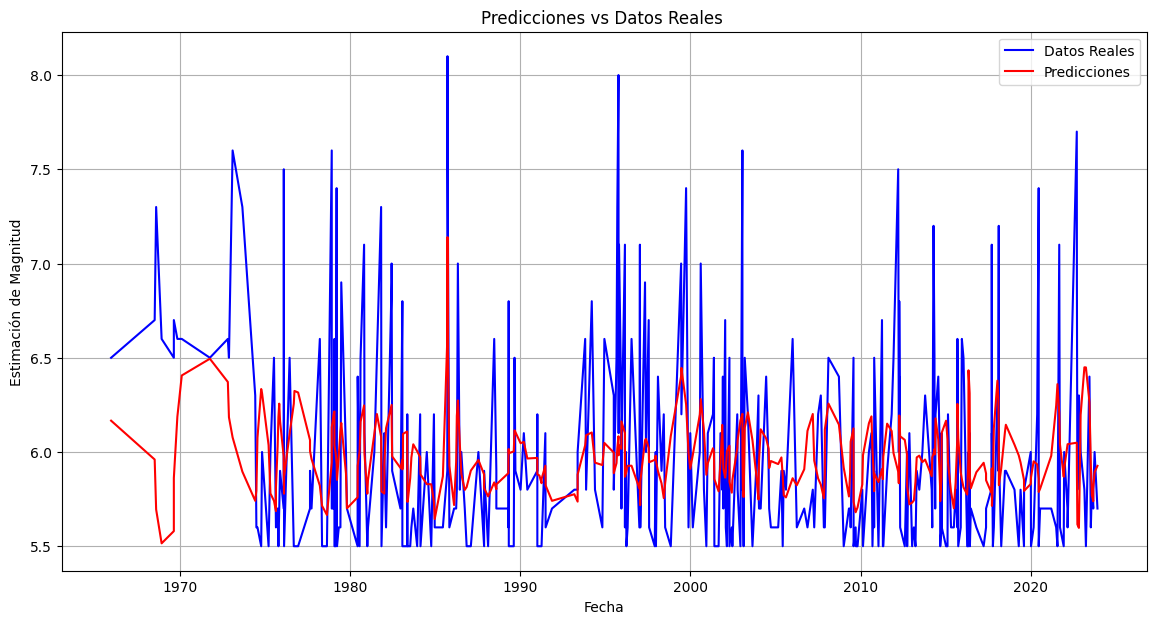

In [56]:
# Graficar
plt.figure(figsize=(14, 7))
plt.plot(data.index, real_demand, label='Datos Reales', color='blue')
plt.plot(data.index[:len(predictions)], predictions, label='Predicciones', color='red')
plt.title('Predicciones vs Datos Reales ')
plt.xlabel('Fecha')
plt.ylabel('Estimación de Magnitud')
plt.legend()
plt.grid(True)
plt.show()


In [60]:


# Asegurarse de que tanto 'real_demand' como 'predictions' tienen el mismo índice de tiempo
real_demand = pd.Series(real_demand[:len(predictions)], index=data.index[:len(predictions)])
predictions_series = pd.Series(predictions, index=data.index[:len(predictions)])

# Crear una lista para almacenar los R-squared de cada mes
r_squared_monthly = []

# Agrupar los datos por mes y calcular el R-squared para cada mes
for month, group in real_demand.groupby(real_demand.index.month):
    # Extraer las predicciones correspondientes para ese mes
    pred_for_month = predictions_series[group.index]

    # Calcular el R-squared
    r_squared = r2_score(group, pred_for_month)

    # Almacenar el resultado
    r_squared_monthly.append((month, r_squared))
    print(f'R-squared para el mes {month}: {r_squared}')

# Crear la figura usando Plotly para una mejor interactividad y presentación
fig = go.Figure()

# Añadir los datos reales a la gráfica
fig.add_trace(go.Scatter(x=data.index, y=real_demand, mode='lines', name='Datos Reales', line=dict(color='blue')))

# Añadir las predicciones a la gráfica
fig.add_trace(go.Scatter(x=data.index[:len(predictions)], y=predictions, mode='lines', name='Predicciones', line=dict(color='red')))

# Configuración adicional del gráfico
fig.update_layout(
    title='Comparación de Predicciones vs Datos Reales',
    xaxis_title='Fecha',
    yaxis_title='Estimación de Magnitud',
    legend_title='Leyenda'
)

# Mostrar la gráfica
fig.show()

# Imprimir los R-squared mensuales
for month, r_squared in r_squared_monthly:
    print(f"R-squared para el mes {month}: {r_squared:.4f}")

R-squared para el mes 1: 0.04088679967280184
R-squared para el mes 2: 0.07910631398737455
R-squared para el mes 3: -0.05514624002755131
R-squared para el mes 4: 0.10700776967064629
R-squared para el mes 5: -0.0701793876993162
R-squared para el mes 6: 0.1865479700295214
R-squared para el mes 7: -0.2519617725477201
R-squared para el mes 8: -0.01081680313091482
R-squared para el mes 9: 0.2677565733787308
R-squared para el mes 10: 0.09453791093888542
R-squared para el mes 11: -0.19534180764174436
R-squared para el mes 12: -0.148772074980986


R-squared para el mes 1: 0.0409
R-squared para el mes 2: 0.0791
R-squared para el mes 3: -0.0551
R-squared para el mes 4: 0.1070
R-squared para el mes 5: -0.0702
R-squared para el mes 6: 0.1865
R-squared para el mes 7: -0.2520
R-squared para el mes 8: -0.0108
R-squared para el mes 9: 0.2678
R-squared para el mes 10: 0.0945
R-squared para el mes 11: -0.1953
R-squared para el mes 12: -0.1488
